In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("data", exist_ok=True)

In [2]:
CONFIDENCE_1 = 0.95
CONFIDENCE_2 = 0.99
TRADING_DAYS = 252

In [3]:
portfolio = pd.read_csv("data/portfolio_returns_log.csv", index_col=0, parse_dates=True).squeeze("columns")
prices = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
weights = pd.read_csv("data/weights.csv", index_col=0)
asset_returns = pd.read_csv("data/returns_log.csv", index_col=0, parse_dates=True)
#print(portfolio)

weight = weights.iloc[:, 0].copy()           # Series
weight = weight.loc[asset_returns.columns]        # align order with returns columns
#print(weight)

In [4]:
# covariance
cov = asset_returns.cov().values # Σ (N x N)
weight_n = weight.values  # w (N,)
# variance portfolio
port_var =  np.dot(weight_n, np.dot(cov, weight_n)) # w' Σ w

marginal_contribution = np.dot(cov, weight_n) # Σ w 
risk_contribution = (weight_n * marginal_contribution) / port_var # w_i (Σw)_i / (w'Σw)

In [5]:
print("\nRisk contribution of each asset:")
for i in range(len(asset_returns.columns)):
    print(asset_returns.columns[i], ":", round(risk_contribution[i] * 100, 2), "%")
    
print("\nStandard deviation of each asset (annualized):")
print(asset_returns.std() * np.sqrt(252))


Risk contribution of each asset:
S&P500 : 12.04 %
EUROSTOXX : 11.15 %
EUR_BOND : 77.0 %
EURUSD : 0.42 %
GOLD : -0.61 %

Standard deviation of each asset (annualized):
S&P500       0.193148
EUROSTOXX    0.186385
EUR_BOND     0.500791
EURUSD       0.071890
GOLD         0.155188
dtype: float64


In [6]:
annualized_return = portfolio.mean() * TRADING_DAYS
annualized_volatility = portfolio.std() * np.sqrt(TRADING_DAYS)
sharpe_ratio = annualized_return / annualized_volatility
port_cum = np.exp(portfolio.cumsum()) 
max_drawdown = -(port_cum / port_cum.cummax() - 1).min()

print("Annualized return:", f"{annualized_return.item():.2%}")
print("Annualized volatility:", f"{annualized_volatility.item():.2%}")
print("Sharpe ratio:", f"{sharpe_ratio.item():.2f}")
print("Max drawdown:", f"{max_drawdown.item():.2%}")

Annualized return: 6.77%
Annualized volatility: 17.99%
Sharpe ratio: 0.38
Max drawdown: 43.51%


VAR (95%): -1.45%
VAR (99%): -2.96%


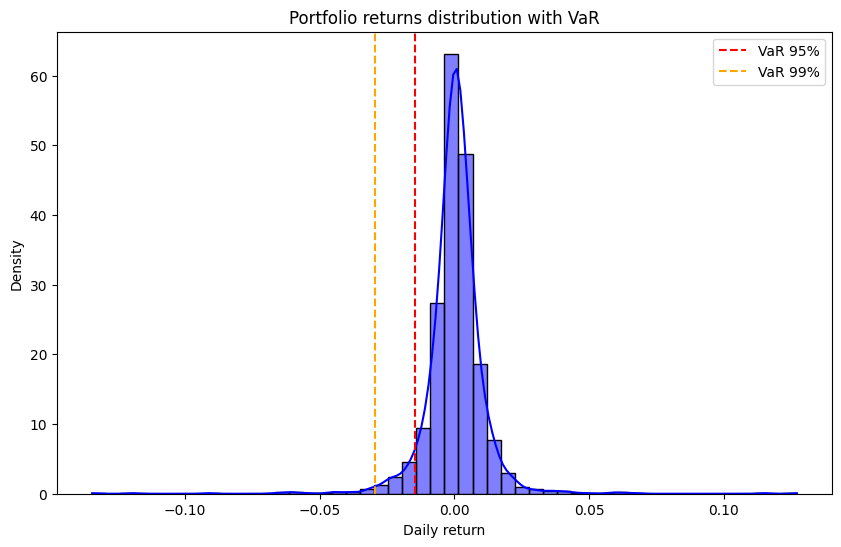

In [7]:
# Historical Simulation VaR calculation 
var_95 = np.percentile(portfolio, (1 - CONFIDENCE_1) * 100)
var_99 = np.percentile(portfolio, (1 - CONFIDENCE_2) * 100)
print(f"VAR (95%): {var_95:.2%}")
print(f"VAR (99%): {var_99:.2%}")

plt.figure(figsize=(10, 6))
sns.histplot(portfolio, bins=50, kde=True, color='blue', stat='density')
plt.axvline(var_95, color='red', linestyle='--', label='VaR 95%')
plt.axvline(var_99, color='orange', linestyle='--', label='VaR 99%')
plt.title("Portfolio returns distribution with VaR")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.legend()
plt.show()

Parametric VAR (95%): -1.84%
Parametric VAR (99%): -2.61%


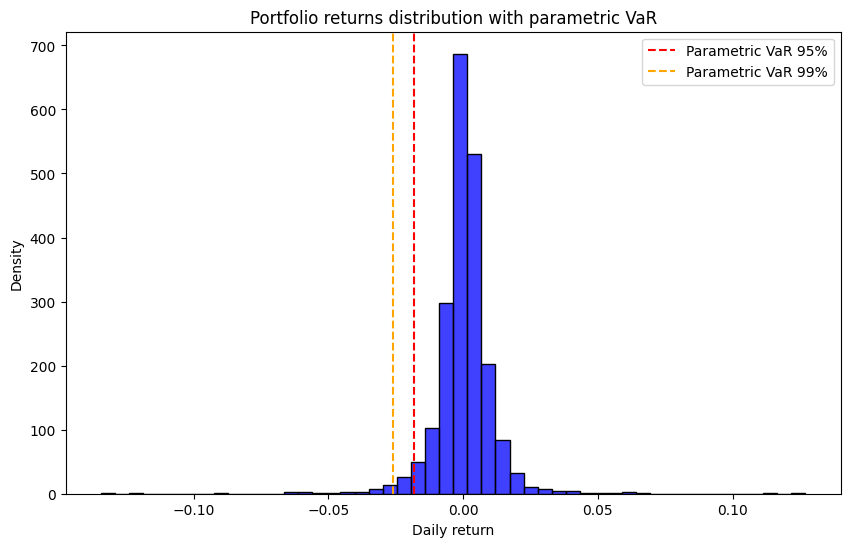

In [8]:
# Parametric VAR calculation
mean_return = portfolio.mean()
std_return = portfolio.std()

z_95 = norm.ppf(1 - CONFIDENCE_1)
z_99 = norm.ppf(1 - CONFIDENCE_2)
var_95_param = mean_return + z_95 * std_return
var_99_param = mean_return + z_99 * std_return

print(f"Parametric VAR (95%): {var_95_param.item():.2%}")
print(f"Parametric VAR (99%): {var_99_param.item():.2%}")

plt.figure(figsize=(10, 6))
sns.histplot(portfolio, bins=50, color='blue')
plt.axvline(var_95_param.item(), color='red', linestyle='--', label='Parametric VaR 95%')
plt.axvline(var_99_param.item(), color='orange', linestyle='--', label='Parametric VaR 99%')
plt.title("Portfolio returns distribution with parametric VaR")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.legend();


Expected Shortfall (95%): -2.67%
Expected Shortfall (99%): -5.33%


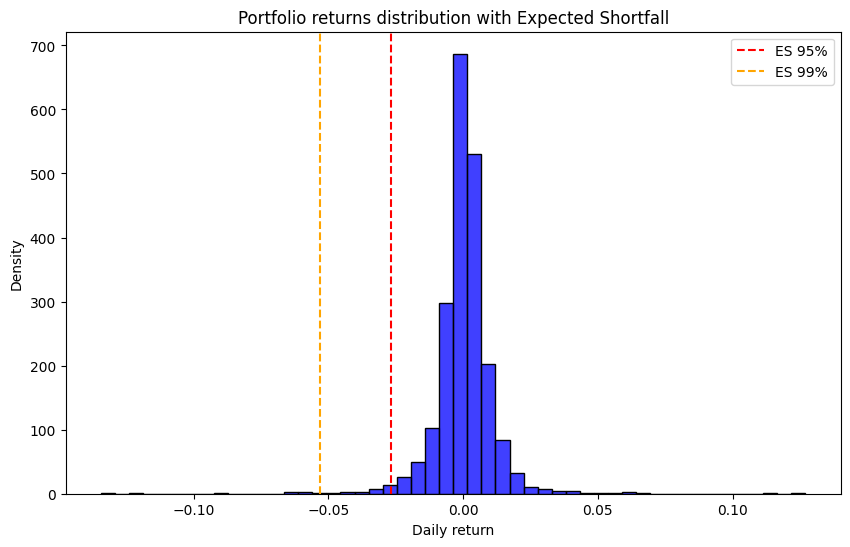

In [9]:
# Expected Shortfall (ES) 
var_95 = np.percentile(portfolio, (1 - CONFIDENCE_1) * 100)
var_99 = np.percentile(portfolio, (1 - CONFIDENCE_2) * 100)
es_95 = portfolio[portfolio <= var_95].mean()
es_99 = portfolio[portfolio <= var_99].mean()

print(f"Expected Shortfall (95%): {es_95.item():.2%}")
print(f"Expected Shortfall (99%): {es_99.item():.2%}")

plt.figure(figsize=(10, 6))
sns.histplot(portfolio, bins=50, color='blue')
plt.axvline(es_95.item(), color='red', linestyle='--', label='ES 95%')
plt.axvline(es_99.item(), color='orange', linestyle='--', label='ES 99%')
plt.title("Portfolio returns distribution with Expected Shortfall")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.legend()
plt.show()


In [10]:
risk_metrics = pd.DataFrame({
    "level": ["95%", "99%"],
    "VaR_Historical": [var_95, var_99],
    "VaR_Parametric": [float(var_95_param), float(var_99_param)],
    "Expected_Shortfall": [float(es_95), float(es_99)],
    "Max_Drawdown": [float(max_drawdown), float(max_drawdown)],
})
risk_metrics.to_csv("data/risk_metrics.csv", index=True)

risk_metrics_summary = pd.DataFrame([{
    "Notebook": "02_Risk_metrics",
    "Window": "full_history",
    "Window_Start": portfolio.index.min().strftime("%Y-%m-%d"),
    "Window_End": portfolio.index.max().strftime("%Y-%m-%d"),
    "VaR_Historical_95": float(var_95),
    "VaR_Historical_99": float(var_99),
    "VaR_Parametric_95": float(var_95_param),
    "VaR_Parametric_99": float(var_99_param),
    "Expected_Shortfall_95": float(es_95),
    "Expected_Shortfall_99": float(es_99),
    "Max_Drawdown": float(max_drawdown),
    "Annualized_Return": float(annualized_return),
    "Annualized_Volatility": float(annualized_volatility),
    "Sharpe_Ratio": float(sharpe_ratio),
    "Scenario_Return": np.nan,
    "Worst_Day": pd.NaT,
    "Worst_Return": np.nan,
    "Historical_VaR_Method": "historical_percentile",
    "Expected_Shortfall_Method": "mean_below_historical_var",
    "Max_Drawdown_Method": "exp_cumsum_vs_cummax",
    "Max_Drawdown_Scope": "full_history",
}])
risk_metrics_summary.to_csv("data/02_risk_metrics_summary.csv", index=False)